This notebook assumes that you already have Julia and FUSE installed (could be the general FUSE version available on the Julia registry or a clone of the version called MaritimeFUSE). If you just want to look at this existing data then for simplicity you can install the general registry version. All the instructions for that installation are here: https://fuse.help/dev/install.html

I have a couple of different environments that contain different versions of FUSE, so this step is only necessary if your environment is configured with multiple versions. If you have only a single version of FUSE you can skip the Pkg.activate step and go straight to using FUSE

In [1]:
using Pkg
Pkg.activate("/Users/adrianaghiozzi/Projects/maritime_dev/MaritimeFUSE_env")

  Activating project at `~/Projects/maritime_dev/MaritimeFUSE_env`


In [5]:
using Plots
using FUSE

pathof(FUSE) shows you where the FUSE version that you're using is located. If you just add the standard Julia registry version of FUSE then this location will be something like /.julia/packages/FUSE, but I cloned my own version so it's in a custom location

In [3]:
pathof(FUSE)

"/Users/adrianaghiozzi/Projects/maritime_dev/MaritimeFUSE/src/FUSE.jl"

This command loads in the json file with all the FUSE data into the object we usually call dd, for data dictionary. Note that the function json2imas lives in the IMAS package which is a dependency of FUSE, but when you install the FUSE registry you can access all the different dependencies directly by doing FUSE.dependency_name instead of having to do using dependency_name for every single one

In [4]:
dd = FUSE.IMAS.json2imas("yinsen_base_design_jan26.json");

A guide to all the data stored in dd (it's a lot) can be found here: https://fuse.help/dev/dd.html, and the links are clickable to show you the definitions of each variable inside dd. Below is a guide to how to access some of the most-used parameters, but if what you're looking for isn't listed below you can use the link above and ctrl+F to search for the parameter you want.

In [6]:
dd.equilibrium

equilibrium
├─ time ➡ [0] [s]
├─ time_slice
│  └─ 1
│     ├─ boundary
│     │  ├─ elongation ➡ 1.79906
│     │  ├─ elongation_lower ➡ Function
│     │  ├─ elongation_upper ➡ Function
│     │  ├─ geometric_axis
│     │  │  ├─ r ➡ 3.17836 [m]
│     │  │  └─ z ➡ 0.000976639 [m]
│     │  ├─ minor_radius ➡ 1.04693 [m]
│     │  ├─ outline
│     │  │  ├─ r ➡ 255-element Vector{Float64} [m]
│     │  │  │      min:2.1   avg:2.96   max:4.23
│     │  │  └─ z ➡ 255-element Vector{Float64} [m]
│     │  │         min:-1.86   avg:0.0167   max:1.86
│     │  ├─ ovality ➡ -0.00587362
│     │  ├─ psi ➡ -0.108127 [Wb]
│     │  ├─ squareness ➡ -0.013701
│     │  ├─ squareness_lower_inner ➡ Function
│     │  ├─ squareness_lower_outer ➡ Function
│     │  ├─ squareness_upper_inner ➡ Function
│     │  ├─ squareness_upper_outer ➡ Function
│     │  ├─ strike_point
│     │  │  ├─ 1
│     │  │  │  ├─ last_closed_flux_surface_gap ➡ 1.37351e-09 [m]
│     │  │  │  ├─ r ➡ 2.34598 [m]
│     │  │  │  └─ z ➡ 2.33632 [m]


The data structure is set up to be able to accommodate time-dependent data, but our data isn't time dependent so you can use this open-bracket notation to access the time slice associated to the so-called "global time". In this case the global time is just 0.0 since there's a single time slice. 

In [7]:
dd.global_time

0.0

In [10]:
dd.equilibrium.time_slice[] # this is equivalent to: 
dd.equilibrium.time_slice[dd.global_time] # which is also equivalent to: 
dd.equilibrium.time_slice[1]

1
├─ boundary
│  ├─ elongation ➡ 1.79906
│  ├─ elongation_lower ➡ Function
│  ├─ elongation_upper ➡ Function
│  ├─ geometric_axis
│  │  ├─ r ➡ 3.17836 [m]
│  │  └─ z ➡ 0.000976639 [m]
│  ├─ minor_radius ➡ 1.04693 [m]
│  ├─ outline
│  │  ├─ r ➡ 255-element Vector{Float64} [m]
│  │  │      min:2.1   avg:2.96   max:4.23
│  │  └─ z ➡ 255-element Vector{Float64} [m]
│  │         min:-1.86   avg:0.0167   max:1.86
│  ├─ ovality ➡ -0.00587362
│  ├─ psi ➡ -0.108127 [Wb]
│  ├─ squareness ➡ -0.013701
│  ├─ squareness_lower_inner ➡ Function
│  ├─ squareness_lower_outer ➡ Function
│  ├─ squareness_upper_inner ➡ Function
│  ├─ squareness_upper_outer ➡ Function
│  ├─ strike_point
│  │  ├─ 1
│  │  │  ├─ last_closed_flux_surface_gap ➡ 1.37351e-09 [m]
│  │  │  ├─ r ➡ 2.34598 [m]
│  │  │  └─ z ➡ 2.33632 [m]
│  │  ├─ 2
│  │  │  ├─ last_closed_flux_surface_gap ➡ 1.37351e-09 [m]
│  │  │  ├─ r ➡ 2.02981 [m]
│  │  │  └─ z ➡ 1.93769 [m]
│  │  ├─ 3
│  │  │  ├─ last_closed_flux_surface_gap ➡ 0.0392291 [m]
│  │  

Many of the IDS's (different categories in the data structure) have plotting "recipes" that are set up in the FUSE source code, so often you can do something like this to get a nice plot: 

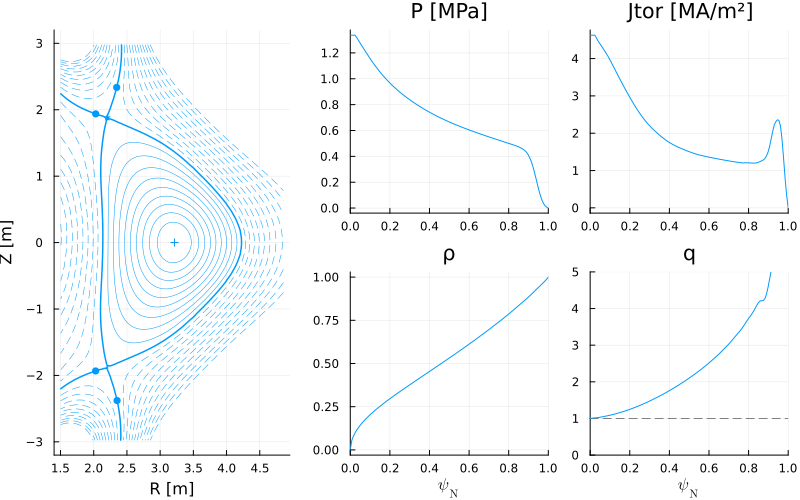

In [11]:
plot(dd.equilibrium)

Similar vibes in core profiles - you can get the time_slice you need with open brackets and you can also plot things easily:

In [12]:
dd.core_profiles.profiles_1d[]

1
├─ conductivity_parallel ➡ Function [ohm^-1.m^-1]
├─ electrons
│  ├─ density ➡ Function [m^-3]
│  ├─ density_fast ➡ 101-element Vector{Float64} [m^-3]
│  │                 all:0   
│  ├─ density_thermal ➡ 101-element Vector{Float64} [m^-3]
│  │                    min:3.39e+19   avg:1.68e+20   max:2.03e+20
│  ├─ pressure ➡ Function [Pa]
│  ├─ pressure_fast_parallel ➡ 101-element Vector{Float64} [Pa]
│  │                           all:0   
│  ├─ pressure_fast_perpendicular ➡ 101-element Vector{Float64} [Pa]
│  │                                all:0   
│  ├─ pressure_thermal ➡ Function [Pa]
│  └─ temperature ➡ 101-element Vector{Float64} [eV]
│                   min:90.5   avg:1.29e+04   max:1.99e+04
├─ grid
│  ├─ area ➡ 101-element Vector{Float64} [m^2]
│  │         min:0   avg:1.88   max:5.37
│  ├─ psi ➡ 101-element Vector{Float64} [Wb]
│  │        min:-23.6   avg:-12.7   max:-0.0897
│  ├─ psi_norm ➡ 101-element Vector{Float64}
│  │             min:0   avg:0.463   max:1
│  ├─ rho_tor_

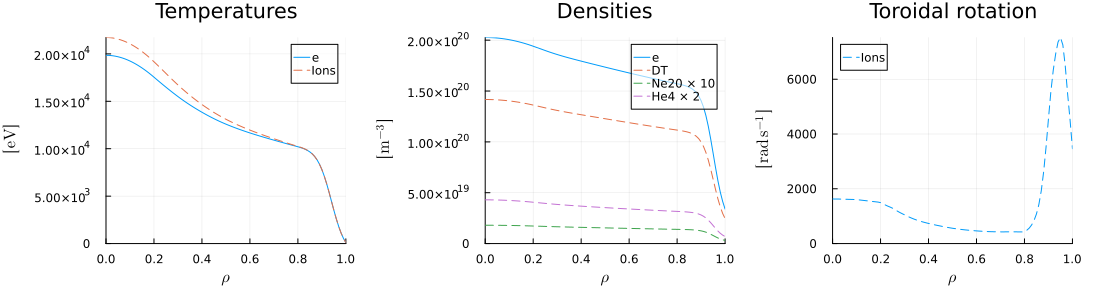

In [13]:
plot(dd.core_profiles)

The help_plot function is helpful to show what options are available for a certain plot:

core_profiles
     time0::Float64 = 0.0  # Time to plot

core_profiles.profiles_1d[:]
     only::Union{Nothing, Int64} = nothing  # Plot only this subplot number
     rotation_quantity::Symbol = :toroidal  # What rotation to plot, one of (:toroidal, :sonic)

core_profiles.profiles_1d[:],Val{:electrons__temperature}
     label::AbstractString = ""  # Label for the plot
     thomson_scattering::Bool = false  # Overlay Thomson scattering data

core_profiles.profiles_1d[:].electrons,Symbol
     normalization::Union{Real, AbstractVector{<:Real}} = 1.0  # Normalization factor
     coordinate::Union{Nothing, Symbol} = nothing  # Coordinate for x-axis
     weighted::Union{Nothing, Symbol} = nothing  # Weighting field
     fill0::Bool = false  # Fill area under curve

core_profiles.profiles_1d[:],Val{:ions__temperature}
     label::AbstractString = ""  # Label for the plot
     charge_exchange::Bool = false  # Overlay charge exchange data

core_profiles.profiles_1d[:].ion[:],Symbol
     normali

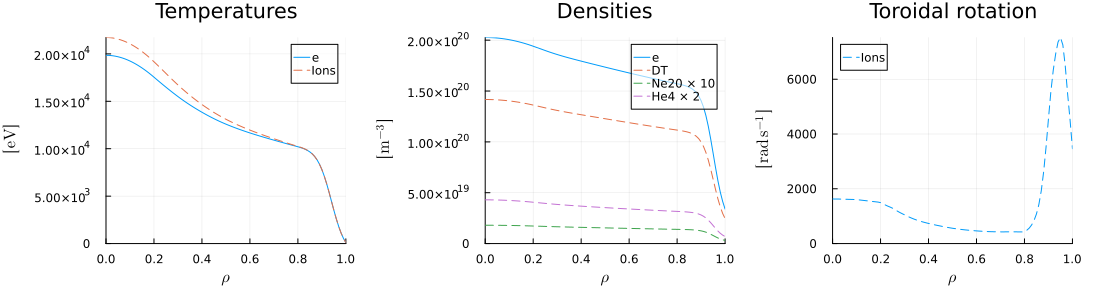

In [14]:
help_plot(dd.core_profiles)

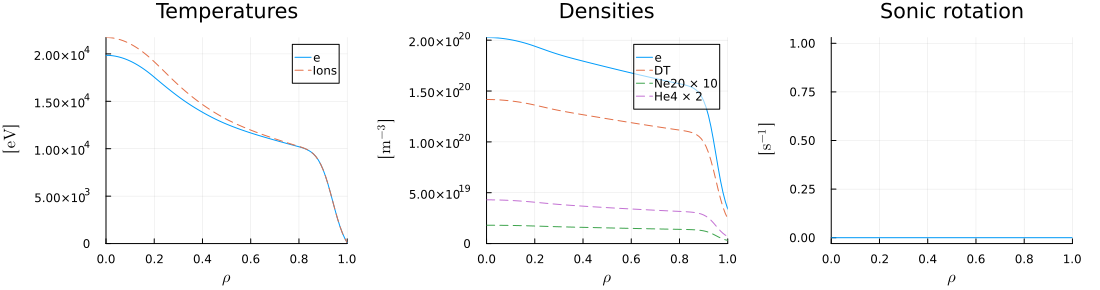

In [15]:
plot(dd.core_profiles; rotation_quantity = :sonic)

Most of the CS/PF related info that comes from the flux swing actor as well as the PF placement actor and HFS/LFS sizing actors can be found in the following places: 

In [16]:
dd.build.tf

tf
├─ coils_n ➡ 16
├─ critical_b_field ➡ 40.6778 [T]
├─ critical_j ➡ 4.2844e+07 [A/m^2]
├─ max_b_field ➡ 19.5276 [T]
├─ max_j ➡ 3.72556e+07 [A/m^2]
├─ nose_hfs_fraction ➡ 0
├─ ripple ➡ 0.01
├─ technology
│  ├─ JxB_strain ➡ 0
│  ├─ fraction_steel ➡ 0.605342
│  ├─ fraction_void ➡ 0.1
│  ├─ material ➡ "rebco"
│  ├─ ratio_SC_to_copper ➡ 1
│  ├─ temperature ➡ 20 [K]
│  └─ thermal_strain ➡ 0
└─ wedge_thickness ➡ Function [m]


In [17]:
dd.build.oh

oh
├─ critical_b_field ➡ 40.6778 [T]
├─ critical_j ➡ 2.9027e+07 [A/m^2]
├─ flattop_duration ➡ 352.182 [s]
├─ max_b_field ➡ 13.8967 [T]
├─ max_j ➡ 2.52409e+07 [A/m^2]
└─ technology
   ├─ JxB_strain ➡ 0
   ├─ fraction_steel ➡ 0.79997
   ├─ fraction_void ➡ 0.1
   ├─ material ➡ "rebco"
   ├─ ratio_SC_to_copper ➡ 1
   ├─ temperature ➡ 20 [K]
   └─ thermal_strain ➡ 0


In [18]:
dd.build.flux_swing

flux_swing
├─ flattop ➡ 7.35243 [Wb]
├─ pf ➡ -10.9226 [Wb]
└─ rampup ➡ 59.8599 [Wb]


In [19]:
dd.build.pf_active

pf_active
├─ rail
│  ├─ 1
│  │  ├─ coils_cleareance ➡ 0.0547657 [m]
│  │  ├─ coils_number ➡ 6
│  │  ├─ name ➡ "OH"
│  │  └─ outline
│  │     ├─ distance ➡ [-1,1] [m]
│  │     ├─ r ➡ [0.792888,0.792888] [m]
│  │     └─ z ➡ [-2.959,3.01544] [m]
│  └─ 2
│     ├─ coils_cleareance ➡ 0.055987 [m]
│     ├─ coils_number ➡ 8
│     ├─ name ➡ "PF"
│     └─ outline
│        ├─ distance ➡ 1608-element Vector{Float64} [m]
│        │             min:-1   avg:0.000742   max:1
│        ├─ r ➡ 1608-element Vector{Float64} [m]
│        │      min:1.52   avg:4.25   max:5.87
│        └─ z ➡ 1608-element Vector{Float64} [m]
│               min:-3.49   avg:0.0321   max:3.55
└─ technology
   ├─ JxB_strain ➡ 0
   ├─ fraction_steel ➡ 0.5
   ├─ fraction_void ➡ 0.1
   ├─ material ➡ "rebco"
   ├─ ratio_SC_to_copper ➡ 1
   ├─ temperature ➡ 20 [K]
   └─ thermal_strain ➡ 0


In [20]:
dd.pf_active

pf_active
└─ coil
   ├─ 1
   │  ├─ b_field_max ➡ 300-element Vector{Float64} [T]
   │  │                min:0.1   avg:15.1   max:30
   │  ├─ b_field_max_timed
   │  │  ├─ data ➡ [13.8967] [T]
   │  │  └─ time ➡ [0] [s]
   │  ├─ current
   │  │  ├─ data ➡ [-1.40358e+07] [A]
   │  │  └─ time ➡ [0] [s]
   │  ├─ current_limit_max ➡ 300×2 Matrix{Float64} [A]
   │  │                      min:1.08e+05   avg:1.33e+06   max:4.58e+06
   │  ├─ element
   │  │  └─ 1
   │  │     ├─ geometry
   │  │     │  ├─ geometry_type ➡ 2
   │  │     │  └─ rectangle
   │  │     │     ├─ height ➡ 0.940975 [m]
   │  │     │     ├─ r ➡ 0.792888 [m]
   │  │     │     ├─ width ➡ 0.438126 [m]
   │  │     │     └─ z ➡ -2.48852 [m]
   │  │     └─ turns_with_sign ➡ 1
   │  ├─ function
   │  │  ├─ 1
   │  │  │  ├─ description ➡ "OH"
   │  │  │  └─ index ➡ 0
   │  │  └─ 2
   │  │     ├─ description ➡ "PF"
   │  │     └─ index ➡ 1
   │  ├─ identifier ➡ "optim"
   │  ├─ name ➡ "OH 1"
   │  └─ temperature ➡ [-1,20] [K]
   ├─